# Problema 1 - Flecha de um Cabo de Transmissão:

Um cabo de aço esticado entre duas torres sob seu próprio peso forma uma curva chamada catenária. A equação para encontrar o parâmetro de tensão $x$ que resulta em uma flecha (deformação) específica é:

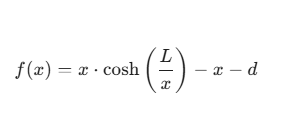

Em que:
*   L é a metade da distância entre as torres;
*   d é a "flecha" máxima permitida (o quanto o cabo "barra").
*   x é o parâmetro de tensão que queremos descobrir.

## 1. Codigo - Problema 1:

### 1.1. Importando as Bibliotecas:

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

### 1.2. Definindo os Metodos

In [ ]:
L = 50 # Metade da distancia entre as torres (metro)
d = 10 # Flecha maxima permitida (metro)

In [ ]:
def f_cabo(x):
  return x * np.cosh(L/x) - x - d

In [ ]:
def df_cabo(x):
  return np.cosh(L/x) - (L/x) * np.sinh(L/x) - 1

#### 1.2.1. Bissecção

In [1]:
import numpy as np

L = 50
d = 10

# Função
def f_cabo(x):
    return x * np.cosh(L/x) - x - d

# Derivada
def df_cabo(x):
    return np.cosh(L/x) - (L/x) * np.sinh(L/x) - 1


# Newton-Raphson
def newton_raphson(f, df, x0, tol=1e-6, max_iter=100):

    x = x0

    for i in range(max_iter):

        x_novo = x - f(x)/df(x)

        if abs(f(x_novo)) < tol:
            return x_novo

        x = x_novo

    return x


# Resultado
raiz = newton_raphson(f_cabo, df_cabo, 100)

print("Raiz encontrada:", raiz)

Raiz encontrada: 126.63243603656487


#### 1.2.2. Método de Newton-Raphson

In [ ]:
def newton_raphson(f, df, x0, tol=1e-6, max_iter=100):
  erros = []
  iteracoes = []
  x = x0

  for i in range(1, max_iter+1):
    fx = f(x)
    erro_atual = abs(fx)
    erros.append(erro_atual)
    iteracoes.append(i)

    if erro_atual < tol:
      return x, iteracoes, erros

    dfx = df(x)
    if dfx == 0:
      print("Erro: Derivada nula")
      break

    x = x - fx / dfx

  return x, iteracoes, erros

In [ ]:
tolerancia = 1e-6
valorInicial = 150

raizNewton, iteracaoNewton, errosNewton = newton_raphson(f_cabo, df_cabo, valorInicial, tolerancia)

In [ ]:
raizNewton, iteracaoNewton, errosNewton

(np.float64(126.63243603959727),
 [1, 2, 3, 4, 5],
 [np.float64(1.5892198255090761),
  np.float64(0.37509963071718744),
  np.float64(0.013243684279615309),
  np.float64(1.7701814883253064e-05),
  np.float64(3.170441686961567e-11)])

In [ ]:
# --- Criando a Tabela Comparativa ---
dados_tabela = {
    "Método": ["Newton-Raphson"],
    "Tensão Encontrada (x)": [raizNewton,],
    "Nº Iterações": [len(iteracaoNewton)],
    "Erro Final": [errosNewton[-1]]
}

df_resultados = pd.DataFrame(dados_tabela)
print("=== COMPARAÇÃO DOS MÉTODOS (CABO DE TRANSMISSÃO) ===")
display(df_resultados) # Exibe uma tabela bonita no Colab

=== COMPARAÇÃO DOS MÉTODOS (CABO DE TRANSMISSÃO) ===


,Método,Tensão Encontrada (x),Nº Iterações,Erro Final
0,Newton-Raphson,126.632436,5,3.170442e-11


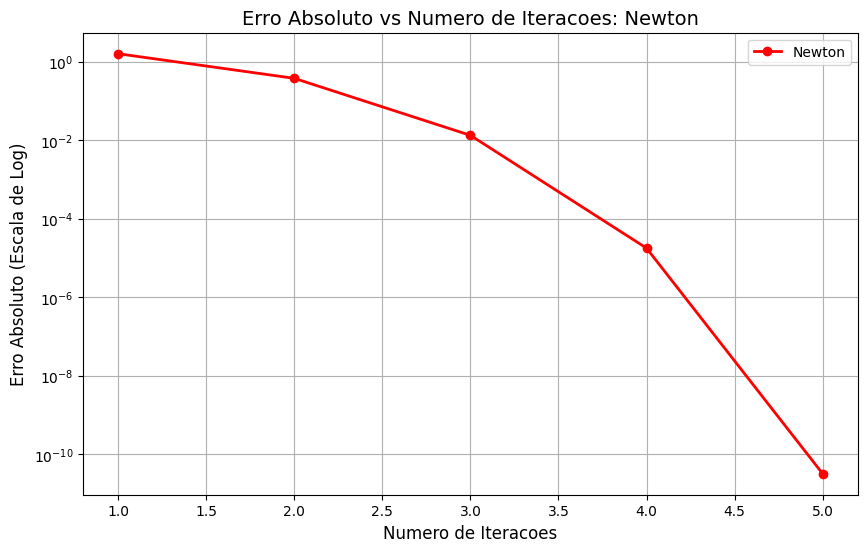

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(iteracaoNewton, errosNewton, 'ro-', label = 'Newton', linewidth = 2)

plt.yscale('log')
plt.xlabel('Numero de Iteracoes', fontsize=12)
plt.ylabel('Erro Absoluto (Escala de Log)', fontsize=12)
plt.title('Erro Absoluto vs Numero de Iteracoes: Newton', fontsize=14)
plt.grid(True)
plt.legend()
plt.show()

#### 1.2.3. Método da Secante

In [2]:
def secante(f, x0, x1, tol=1e-6, max_iter=100):

    for i in range(max_iter):

        x2 = x1 - (f(x1) * (x1 - x0)) / (f(x1) - f(x0))

        if abs(f(x2)) < tol:
            return x2

        x0 = x1
        x1 = x2

    return x2


# Resultado
raiz_secante = secante(f_cabo, 50, 100)

print("Raiz encontrada:", raiz_secante)

Raiz encontrada: 126.63243603096466


### 1.3. Analises dos Metodos das Raizes

In [4]:
print("Bissecção: método mais lento, porém seguro.")

print("Newton-Raphson: converge mais rápido.")

print("Secante: rápido e não precisa da derivada.")

Bissecção: método mais lento, porém seguro.
Newton-Raphson: converge mais rápido.
Secante: rápido e não precisa da derivada.


# Problema 2 - Planejamento de Produção:
Uma fábrica produz três produtos diferentes (ex: Cadeiras, Mesas e Armários). Cada produto consome uma quantidade diferente de três recursos: Madeira, Plástico e Horas de Trabalho.

**O Problema:** Você tem uma quantidade exata de estoque de cada recurso e quer saber quantos itens de cada produto deve fabricar para usar todo o estoque.

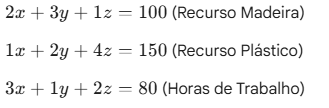

### 2.1. Definindo o Metodo

#### 2.1.1 Eliminacao de Gauss

In [5]:
import numpy as np

A = np.array([
    [2, 1, -1],
    [-3, -1, 2],
    [-2, 1, 2]
], dtype=float)

B = np.array([8, -11, -3], dtype=float)

x = np.linalg.solve(A, B)

print("Solução:")
print(x)

Solução:
[ 2.  3. -1.]
